In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# NOTE: uncomment export_metrics_to_csv caller in ultralytics/utils/metrics.py to generate the csv file, then run validation
df = pd.read_csv("runs\\dist\\val120\\distance_error_analysis.csv")

df["abs_error"] = np.abs(df["pred_dist"] - df["target_dist"])
df["rel_error"] = df["abs_error"] / (np.abs(df["target_dist"]) + 1e-9)

dfs = df.sort_values("target_dist")

In [82]:
# linear
coef_lin = np.polyfit(df["target_dist"], df["abs_error"], 1)
r2_lin = r2_score(df["abs_error"], np.poly1d(coef_lin)(df["target_dist"]))
print("R2 linear:", r2_lin)

# quadratic
coef_quad = np.polyfit(df["target_dist"], df["abs_error"], 2)
r2_quad = r2_score(df["abs_error"], np.poly1d(coef_quad)(df["target_dist"]))
print("R2 quadratic:", r2_quad)

R2 linear: 0.15640716180232672
R2 quadratic: 0.15784406144367558


y = 0.027579x + 0.215085


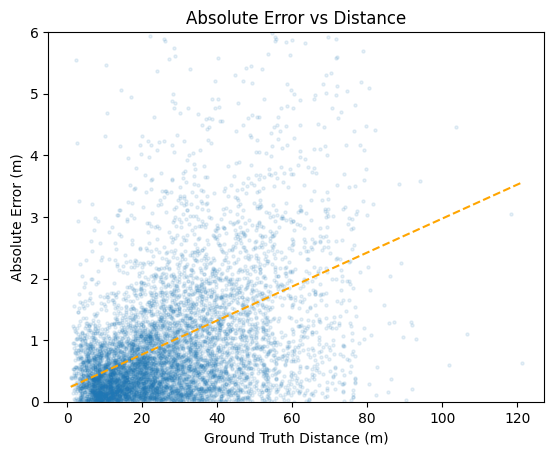

In [83]:
# linear fit (absolute error)
coef = np.polyfit(dfs["target_dist"], dfs["abs_error"], 1)
print(f"y = {coef[0]:.6f}x + {coef[1]:.6f}")

poly1d_fn = np.poly1d(coef)

x_line = np.linspace(dfs['target_dist'].min(), dfs['target_dist'].max(), 100)
y_line = poly1d_fn(x_line)

plt.figure()
plt.scatter(dfs["target_dist"], dfs["abs_error"], s=5, alpha=0.1)
plt.plot(x_line, y_line, linestyle="--", color="orange")
plt.xlabel("Ground Truth Distance (m)")
plt.ylabel("Absolute Error (m)")
plt.title("Absolute Error vs Distance")
plt.ylim(0, 6)
plt.show()

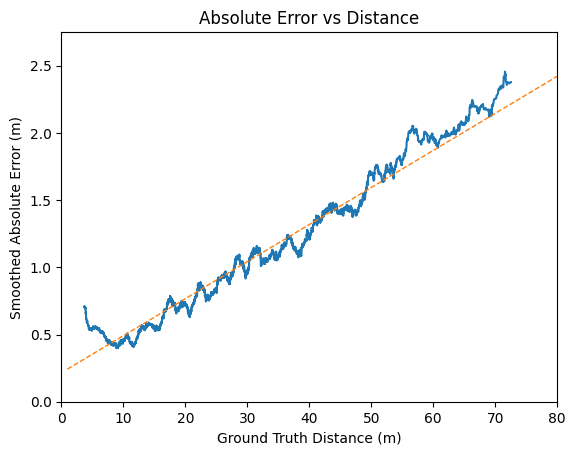

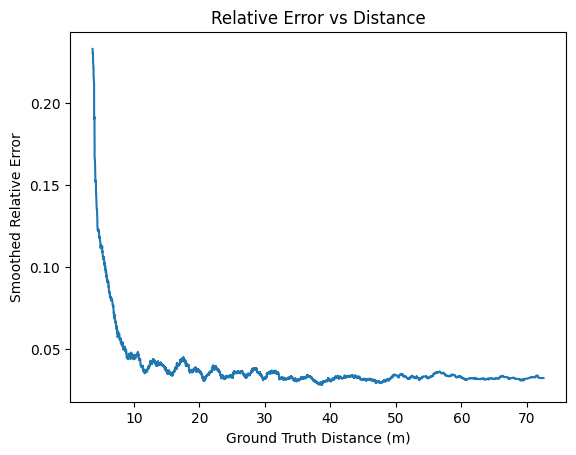

In [84]:
# moving averages
window_size = 250
dfs["mae_smooth"] = dfs["abs_error"].rolling(window_size, center=True).mean()
dfs["mre_smooth"] = dfs["rel_error"].rolling(window_size, center=True).mean()

# absolute error figure
plt.figure()
plt.plot(dfs["target_dist"], dfs["mae_smooth"])
plt.plot(x_line, y_line, linestyle="--", linewidth=1)
plt.xlabel("Ground Truth Distance (m)")
plt.ylabel("Smoothed Absolute Error (m)")
plt.title("Absolute Error vs Distance")
plt.xlim(0, 80)
plt.ylim(0, 2.75)
plt.show()

# relative error figure
plt.figure()
plt.plot(dfs["target_dist"], dfs["mre_smooth"])
plt.xlabel("Ground Truth Distance (m)")
plt.ylabel("Smoothed Relative Error")
plt.title("Relative Error vs Distance")
plt.show()

In [ ]:
bins = np.arange(0, df["target_dist"].max() + 5, 10)

df["distance_bin"] = pd.cut(df["target_dist"], bins)

interval_table = df.groupby("distance_bin").agg(
    count=("abs_error", "count"),
    MAE=("abs_error", "mean"),
    MRE=("rel_error", "mean")
)

interval_table = interval_table.reset_index()
interval_table.head(15)
